# Movie Recommendation System — Collaborative Filtering

A movie recommender built on the **MovieLens 100k** dataset, implementing three
classic collaborative filtering approaches and deploying the result as a live demo.

**Techniques implemented:**
- **User-based CF** — recommends movies liked by users with similar taste
- **Item-based CF** — recommends movies similar to ones a user already rated highly
- **SVD Matrix Factorization** — learns latent user/movie factors via `TruncatedSVD`

**Deployment:** a simple [Gradio](https://gradio.app) app where you enter a User ID
and get top-5 movie recommendations.

**Dataset:** [MovieLens 100k](https://grouplens.org/datasets/movielens/100k/) —
100,000 ratings from 943 users on 1,682 movies.

### Step 0: Download & prepare the dataset

In [ ]:
!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip ml-100k.zip

import pandas as pd
ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                     names=['userId', 'movieId', 'rating', 'timestamp'])
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                    usecols=[0,1], names=['movieId', 'title'])

ratings.to_csv('ratings.csv', index=False) #/content
movies.to_csv('movies.csv', index=False) #/content/sample_data
print("✅ Files ready!")


--2026-03-06 05:01:42--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  16.2MB/s    in 0.3s    

2026-03-06 05:01:42 (16.2 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.ba

### **STEP 1**: SETUP & DATA LOADING

In [ ]:

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity  # Computes similarity between vectors
from sklearn.decomposition import TruncatedSVD         # Matrix factorization (latent factors)
import matplotlib.pyplot as plt
import seaborn as sns

- Load MovieLens dataset:
- ratings.csv: userId (who), movieId (what), rating (1-5 stars)
- movies.csv: movieId, title (for readable output)

In [ ]:
ratings = pd.read_csv('ratings.csv')  # Shape: ~100k rows x 3 cols
movies = pd.read_csv('movies.csv')    # Shape: ~1.7k movies x 2 cols
print("Ratings shape:", ratings.shape)
print(ratings.head())
print("=======")
print(movies.head())

Ratings shape: (100000, 4)
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
   movieId              title
0        1   Toy Story (1995)
1        2   GoldenEye (1995)
2        3  Four Rooms (1995)
3        4  Get Shorty (1995)
4        5     Copycat (1995)


In [ ]:
len(movies)

1682

In [ ]:

len(ratings)

100000

In [ ]:
ratings['userId'].unique().max()

np.int64(943)

### **STEP 2**: CREATE USER-ITEM RATING MATRIX
### Pivot ratings into sparse matrix: </br>
### Rows = users, Columns = movies, Values = ratings (0 = not watched) </br>

In [ ]:
user_item_matrix = ratings.pivot_table(
    index='userId',          # Each row = one unique user
    columns='movieId',       # Each column = one unique movie
    values='rating'          # Cell value = rating (1-5), NaN → 0
).fillna(0)                     # Fill missing ratings with 0 (not watched)

print(f"Matrix shape: {user_item_matrix.shape}")  # e.g., (943 users, 1682 movies)
print(user_item_matrix.head())  # Sparse matrix preview

Matrix shape: (943, 1682)
movieId  1     2     3     4     5     6     7     8     9     10    ...  \
userId                                                               ...   
1         5.0   3.0   4.0   3.0   3.0   5.0   4.0   1.0   5.0   3.0  ...   
2         4.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   2.0  ...   
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
5         4.0   3.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   

movieId  1673  1674  1675  1676  1677  1678  1679  1680  1681  1682  
userId                                                               
1         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
2         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
5         0.0   0.0  

### **STEP 3**: USER-BASED COLLABORATIVE FILTERING
### "Users who liked similar movies will like these too!"

### Compute cosine similarity between ALL user rating vectors
### Cosine: measures angle between vectors (1=identical tastes, 0=orthogonal)

**Note:** each row of `user_item_matrix` is a user's rating vector across all 1,682 movies — this is what cosine similarity compares between users.

In [ ]:
user_similarity = cosine_similarity(user_item_matrix)  # Shape: (n_users, n_users)

# Convert to labeled DataFrame for easy lookup
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,      # Row labels = user IDs
    columns=user_item_matrix.index     # Column labels = user IDs
)

print(user_similarity_df.head())

userId       1         2         3         4         5         6         7    \
userId                                                                         
1       1.000000  0.166931  0.047460  0.064358  0.378475  0.430239  0.440367   
2       0.166931  1.000000  0.110591  0.178121  0.072979  0.245843  0.107328   
3       0.047460  0.110591  1.000000  0.344151  0.021245  0.072415  0.066137   
4       0.064358  0.178121  0.344151  1.000000  0.031804  0.068044  0.091230   
5       0.378475  0.072979  0.021245  0.031804  1.000000  0.237286  0.373600   

userId       8         9         10   ...       934       935       936  \
userId                                ...                                 
1       0.319072  0.078138  0.376544  ...  0.369527  0.119482  0.274876   
2       0.103344  0.161048  0.159862  ...  0.156986  0.307942  0.358789   
3       0.083060  0.061040  0.065151  ...  0.031875  0.042753  0.163829   
4       0.188060  0.101284  0.060859  ...  0.052107  0.036784  0

In [ ]:
def get_user_recommendations(user_id, n_recommendations=10):
    """
    Recommend movies for target user based on TOP 10 similar users' tastes

    Args:
        user_id: Target user ID (int)
        n_recommendations: Number of movies to recommend

    Returns:
        DataFrame: movieId, predicted score (sorted descending)
    """
    # Get TOP 10 most similar users (exclude self: [1:11])
    # Select column for target user from similarity matrix
    # Highest similarity first- TOP 10 most similar users, excluding self
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]

    '''
     output is a series object
     user_id  similarity_score
     ---       ------ (1)


     ---       ------ (10)
    '''

    # Weighted average prediction:
    # For each unwatched movie: sum(similar_user_rating * similarity_score)
    weighted_scores = {}
    for sim_user in similar_users.index:  # Loop through similar users
        sim_score = similar_users[sim_user]  # Similarity weight (0-1)
        for movie in user_item_matrix.columns:  # All movies
            if user_item_matrix.loc[user_id, movie] == 0:  # Target user hasn't rated
                # Accumulate weighted rating
                # predicted_rating = Σ (similar_user_rating × similarity_weight)
                ## Example : Similar User 152: rated Movie 42 = 4.5⭐, similarity = 0.92 → Contribution = 4.5 × 0.92 = 4.14
                ##Similar User 45:  rated Movie 42 = 3.0⭐, similarity = 0.87   → Contribution = 3.0 × 0.87 = 2.6
                weighted_scores[movie] = weighted_scores.get(movie, 0) + \
                                       (user_item_matrix.loc[sim_user, movie] * sim_score)

    # Convert to DataFrame and rank by score
    recommendations = pd.DataFrame.from_dict(weighted_scores, orient='index')
    recommendations.columns = ['score']
    return recommendations.sort_values('score', ascending=False).head(n_recommendations)

#### STEP 4: ITEM-BASED COLLABORATIVE FILTERING
#### "Users who liked this movie also liked..."

In [ ]:
# Compute similarity between ALL movie rating vectors (transpose matrix)
item_similarity = cosine_similarity(user_item_matrix.T)  # Shape: (n_movies, n_movies)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,    # Row labels = movie IDs
    columns=user_item_matrix.columns   # Column labels = movie IDs
)

In [ ]:
def get_item_recommendations(movie_id, n_recommendations=10, user_id=1):
    """
    Recommend similar movies based on movies with similar audience tastes
    """
    # TOP 10 most similar movies to target movie
    similar_movies = item_similarity_df[movie_id].sort_values(ascending=False)[1:11]

    weighted_scores = {}
    user_ratings = user_item_matrix.loc[user_id]  # This user's ratings

    # Weight similar movies by how much target user liked the seed movie
    for sim_movie in similar_movies.index:
        weight = similar_movies[sim_movie] * user_ratings[movie_id]  # User's preference for seed
        weighted_scores[sim_movie] = weight

    # Return ranked recommendations
    rec_df = pd.DataFrame.from_dict(weighted_scores, orient='index')
    rec_df.columns = [0]  # Fix column name
    return rec_df.sort_values(0, ascending=False).head(n_recommendations)

#### STEP 5: MATRIX FACTORIZATION (SVD)
### Get latent factors: "Users who like Action like Sci-Fi too!"

| Aspect       | SVD (Full)                               | TruncatedSVD                           |
| ------------ | ---------------------------------------- | -------------------------------------- |
| Computes     | ALL singular values (full decomposition) | TOP-K only (truncated)                 |
| Matrix Type  | Dense only (NumPy arrays)                | Sparse + Dense (SciPy sparse matrices) |
| Speed        |  Slow (O(min(m,n)^3))                  | Fast (randomized O(mn log k))        |
| Memory       | High (stores everything)              |  Low (only K components)             |
| Scikit-learn |  Not available                          |  sklearn.decomposition.TruncatedSVD   |

In [ ]:
# SVD decomposes matrix into user_factors × item_factors
svd = TruncatedSVD(n_components=50)  # 50 latent dimensions (genres/themes)
user_factors = svd.fit_transform(user_item_matrix)    # Shape: (n_users, 50)
item_factors = svd.components_.T                       # Shape: (n_movies, 50)

In [ ]:
def predict_rating(user_id, movie_id):
    """Predict rating = dot product of user & item latent factors

       # Example: Find User ID = 152 in index [1, 45, 152, 289, ...]
        user_item_matrix.index == 152
        # Returns: [False, False, True, False, ...]  ← Boolean mask (943 elements)

        np.where([False, False, True, False, ...])
        # Returns: array([152])  ← Array containing POSITION of True (index 152)

        np.where(...)[0]      # Returns: array([152])  ← First (only) match
        np.where(...)[0][0]   # Returns: 152           ← SINGLE INTEG
        1. DataFrames → NumPy indexing
        2. Find row/col position → Integer needed
        3. np.where() → Always returns array([pos])
        4. Extract with [0][0] → Single integer!

    """
    user_idx = np.where(user_item_matrix.index == user_id)[0][0]  # User's factor row
    movie_idx = np.where(user_item_matrix.columns == movie_id)[0][0]  # Movie's factor row
    return user_factors[user_idx].dot(item_factors[movie_idx])  # Latent similarity

In [ ]:
def svd_recommendations(user_id, n=10):
    """Generate top-N recommendations using SVD predictions"""
    user_idx = np.where(user_item_matrix.index == user_id)[0][0]
    predictions = {}

    for movie_id in user_item_matrix.columns:
        if user_item_matrix.loc[user_id, movie_id] == 0:  # Unwatched movies only
            predictions[movie_id] = predict_rating(user_id, movie_id)

    rec_df = pd.DataFrame.from_dict(predictions, orient='index')
    rec_df.columns = [0]
    return rec_df.sort_values(0, ascending=False).head(n)


#### STEP 6: COMPLETE The flow & EVALUATION
#### Test all methods for user 1

=== User-Based Collaborative Filtering ===
         score
318  21.996880
474  21.006675
655  19.883163
423  19.857810
403  19.788317

=== SVD Matrix Factorization ===
            0
732  3.479454
511  3.122302
692  2.913860
408  2.832034
385  2.794879

Precision@10 (User-based): 0.000
Precision@10 (SVD): 0.000


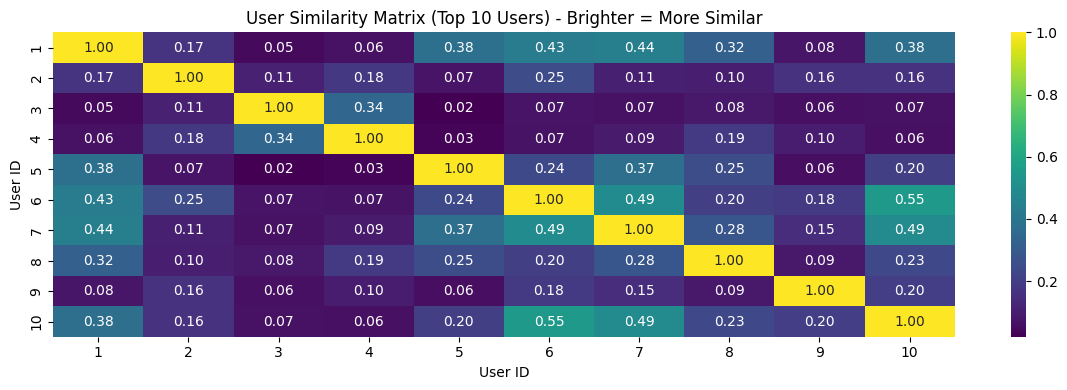

In [ ]:
user_id = 1
print("=== User-Based Collaborative Filtering ===")
user_recs = get_user_recommendations(user_id).head()
print(user_recs)

print("\n=== SVD Matrix Factorization ===")
svd_recs = svd_recommendations(user_id).head()
print(svd_recs)

# Precision@K Evaluation (fraction of top-K recs that are actually good ≥4 stars)
def precision_at_k(recommendations, actual_ratings, k=10):
    """
    Precision@K: % of top K recommendations that user actually rated ≥4
    Args:
        recommendations: DataFrame with movieIds (index) and scores
        actual_ratings: User's actual rating series
        k: Top K recommendations to evaluate
    """
    top_k_movies = recommendations.head(k).index  # Top K recommended movie IDs
    relevant_items = sum(actual_ratings.loc[top_k_movies] >= 4)  # Count 4+ star ratings
    return relevant_items / k  # Precision = relevant / retrieved

user_ratings = user_item_matrix.loc[user_id]  # User 1's actual ratings
print(f"\nPrecision@10 (User-based): {precision_at_k(user_recs, user_ratings):.3f}")
print(f"Precision@10 (SVD): {precision_at_k(svd_recs, user_ratings):.3f}")

# Visualize user similarities (heatmap)
plt.figure(figsize=(12, 4))
sns.heatmap(
    user_similarity_df.iloc[:10, :10],  # Top 10 users x Top 10 users
    cmap='viridis',
    annot=True,  # Show similarity values
    fmt='.2f'
)
plt.title('User Similarity Matrix (Top 10 Users) - Brighter = More Similar')
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()

In [ ]:
## STEP 7: DEPLOY INTERACTIVE WEB APP (Gradio)
import gradio as gr

def recommend_movies(user_id):
    """
    Gradio interface: Input user ID → Output top 5 movie titles
    """
    recs = svd_recommendations(int(user_id)).head(5)
    # Join with movie titles for human-readable output
    movie_titles = movies[movies['movieId'].isin(recs.index)]['title'].tolist()
    return f"🎬 Top 5 Recommendations:\n" + " | ".join(movie_titles[:5])

# Create web interface (runs on http://localhost:7860)
demo = gr.Interface(
    fn=recommend_movies,
    inputs=gr.Number(label="👤 Enter User ID (1-943)", value=1),
    outputs=gr.Textbox(label="🎥 Recommended Movies"),
    title="🍿 Movie Recommender - Collaborative Filtering Demo",
    description="User-based + Item-based + SVD Matrix Factorization\nTry different User IDs!"
)

demo.launch(share=True)  # share=True creates public link

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4fce2189556fbadcf5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
